## Product Features & Listing Segments

This notebook adds another layer of EDA and feature engineering because the raw columns didn't clearly explain what kind of stay each listing offers.

The earlier EDA helped me look at amenities one by one, but that only gets so far. I was more interested in finding a pattern and grouping listings by type. For example, a crib, high chair, washer, kitchen, and extra bedrooms together say more about a family-friendly stay than any one feature by itself.

In this notebook, I create broader product scores for things like family-friendly stays, work-friendly stays, leisure features, amenity strength, host quality, pricing competitiveness, and demand tier.

The goal is to make the dataset more useful for recommendations. Instead of only asking which features are correlated with demand, I can start asking what type of listing this is and how it compares to similar listings.

This also helps turn the project into more of a host tool, where a host could understand their listing’s strengths, weaknesses, and possible positioning in the local market.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('../data/processed/airbnb_preprocessed.csv')

In [3]:
df.shape

(210525, 82)

In [4]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_wifi,amenity_workspace,city,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log,room_type
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,1,0,Asheville,4.615121,4.532599,0.693147,1.098612,0.693147,0.693147,Entire home/apt
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,1,0,Asheville,4.615121,5.950643,0.693147,1.098612,0.693147,0.693147,Entire home/apt
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,1,0,Asheville,4.204693,4.219508,0.693147,1.098612,0.693147,1.252763,Private room
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,1,1,Asheville,3.828641,4.204693,0.693147,1.098612,0.693147,0.693147,Private room
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,1,1,Asheville,4.615121,4.110874,1.098612,1.609438,0.693147,0.693147,Entire home/apt


In [5]:
df.columns

Index(['id', 'host_id', 'room_type_hotel_room', 'room_type_private_room',
       'room_type_shared_room', 'accommodates', 'bedrooms', 'beds',
       'bathrooms', 'host_is_superhost', 'host_response_time_ord', 'price',
       'latitude', 'longitude', 'number_of_reviews', 'reviews_per_month',
       'review_scores_rating', 'instant_bookable', 'amenity_air_conditioning',
       'amenity_bathtub', 'amenity_bbq_grill', 'amenity_beach_access',
       'amenity_bed_linens', 'amenity_blender',
       'amenity_carbon_monoxide_alarm', 'amenity_cleaning_supplies',
       'amenity_coffee_maker', 'amenity_cooking_basics', 'amenity_dishwasher',
       'amenity_dryer', 'amenity_essentials', 'amenity_ev_charger',
       'amenity_fan', 'amenity_fire_extinguisher', 'amenity_fireplace',
       'amenity_first_aid_kit', 'amenity_flexible_checkin',
       'amenity_game_console', 'amenity_gym', 'amenity_hair_dryer',
       'amenity_hangers', 'amenity_heating', 'amenity_host_services',
       'amenity_hot_tub'

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210525 entries, 0 to 210524
Data columns (total 82 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             210525 non-null  int64  
 1   host_id                        210525 non-null  int64  
 2   room_type_hotel_room           210525 non-null  int64  
 3   room_type_private_room         210525 non-null  int64  
 4   room_type_shared_room          210525 non-null  int64  
 5   accommodates                   210525 non-null  int64  
 6   bedrooms                       210525 non-null  float64
 7   beds                           210525 non-null  float64
 8   bathrooms                      210525 non-null  float64
 9   host_is_superhost              210525 non-null  float64
 10  host_response_time_ord         210525 non-null  float64
 11  price                          210525 non-null  float64
 12  latitude                       210525 non

In [7]:
# cleaning city names so grouped analysis does not split the same market into separate labels
df['city'] = df['city'].replace({
    'Dever': 'Denver', 'Nyc': 'NYC'})

In [90]:
# ran into an issue with some cities being dropped, using this cell to confirm counts

start_city_counts = df['city'].value_counts().reset_index()
start_city_counts.columns = ['city', 'start_count']

df['city'].value_counts()

city
NYC              32550
Los Angeles      30518
Hawaii           23642
Broward          13988
Austin           11214
San Diego        10872
Clark County     10191
Nashville         7190
Chicago           6231
New Orleans       6141
San Francisco     5556
Seattle           5279
Washington Dc     5032
Santa Clara       4952
Dallas            4684
Denver            4390
Portland          3956
Rhode Island      3889
Twin Cities       3856
Asheville         2911
San Mateo         2658
Oakland           2083
Columbus          2049
Santa Cruz        1468
Fort Worth        1403
Newark            1164
Jersey City       1007
Cambridge          763
Bozeman            466
Salem              240
Pacific Grove      182
Name: count, dtype: int64

### Family-Friendly Score

This score gives an idea about how well a listing is suited for family travel. Features like capacity, bedrooms, kitchen/laundry, parking, bathtub, and kid-specific amenities would be most helpful. It's not a true identifier, but it could help with guest filtering and host guidance. 

If I were to take it a step further, I'd identify locations within a radius of family activities like playgrounds, amusement parks, etc. 

In [9]:
family_cols = [
    'amenity_kids_amenities',
    'amenity_kitchen',
    'amenity_washer',
    'amenity_dryer',
    'amenity_bathtub',
    'amenity_parking_free']

df[family_cols].sum().sort_values(ascending=False)

amenity_kitchen           190055
amenity_parking_free      167371
amenity_washer            150989
amenity_dryer             145216
amenity_bathtub            84213
amenity_kids_amenities     72557
dtype: int64

In [10]:
df['family_friendly_score'] = (
    df['amenity_kids_amenities'] * 25 +
    df['amenity_kitchen'] * 15 +
    df['amenity_washer'] * 15 +
    df['amenity_dryer'] * 15 +
    df['amenity_bathtub'] * 10 +
    df['amenity_parking_free'] * 10 +
    (df['accommodates'] >= 4).astype(int) * 10)

In [11]:
df['family_friendly_score'].describe()

count    210525.000000
mean         60.741171
std          25.882532
min           0.000000
25%          45.000000
50%          65.000000
75%          80.000000
max         100.000000
Name: family_friendly_score, dtype: float64

In [12]:
df[
    ['id', 'city', 'room_type', 'accommodates', 'bedrooms', 'bathrooms',
     'price', 'reviews_per_month', 'family_friendly_score']
].sort_values('family_friendly_score', ascending=False).head()

,id,city,room_type,accommodates,bedrooms,bathrooms,price,reviews_per_month,family_friendly_score
7,304379,Asheville,Entire home/apt,4,2.0,1.0,289.0,0.18,100
54311,45817397,Denver,Entire home/apt,4,2.0,1.0,132.0,3.35,100
54316,45859702,Denver,Entire home/apt,5,2.0,2.5,308.0,3.45,100
54317,45863602,Denver,Entire home/apt,9,3.0,3.5,207.0,4.37,100
54331,45935645,Denver,Entire home/apt,6,3.0,2.0,192.0,3.72,100


### Family-Friendly Score vs. Demand

Now that the family-friendly score is created, I want to see whether higher-scoring listings also show stronger demand. Since reviews per month is being used as a demand proxy, this comparison can help show whether family-oriented features are associated with more booking activity. This won't prove that family-friendly listings cause higher demand, but it tell me if it's worth moving forward.

In [13]:
# grouping listings by family-friendly score to compare average demand
family_score_summary = (
    df.groupby('family_friendly_score')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean')
    )
    .reset_index())

family_score_summary

,family_friendly_score,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,0,2486,1.878150,0.78,148.396621
1,10,5728,2.223378,1.42,132.449721
2,15,6761,0.807079,0.23,108.608342
3,20,2142,2.114823,1.53,141.800654
4,25,13975,1.629159,0.98,131.081789
5,30,1985,1.327264,0.67,129.547607
6,35,10660,1.943184,1.34,178.155535
7,40,5679,1.395570,0.86,139.742912
8,45,11677,1.306699,0.51,151.537552
9,50,7301,1.911394,1.28,190.632379


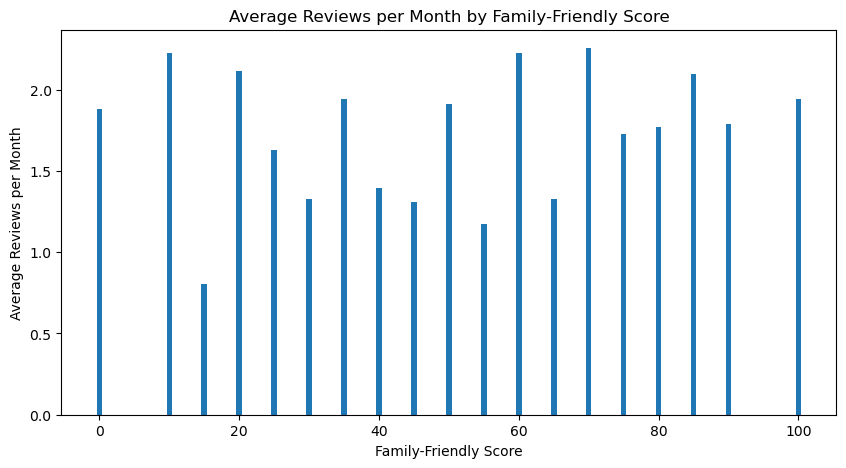

In [14]:
# plotting average demand by family-friendly score to see if there is a visible pattern
plt.figure(figsize=(10, 5))
plt.bar(family_score_summary['family_friendly_score'], family_score_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Family-Friendly Score')
plt.xlabel('Family-Friendly Score')
plt.ylabel('Average Reviews per Month')
plt.show()

### Family-Friendly Score Tiers

The individual score values are useful, but the pattern is a little noisy when every score is shown separately. To make this easier to interpret, I’m grouping the scores into broader tiers. This gives a clearer view of whether listings with stronger family-friendly features tend to show higher demand or pricing patterns.

In [15]:
# grouping family-friendly scores into broader tiers so the pattern is easier to read
df['family_friendly_tier'] = pd.cut(
    df['family_friendly_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across family-friendly tiers
family_tier_summary = (
    df.groupby('family_friendly_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

family_tier_summary

,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,31092,1.613235,0.86,128.569793
1,medium,37302,1.621570,1.00,163.830384
2,high,87855,1.459934,0.89,222.500393
3,very high,54276,1.864145,1.44,286.977504


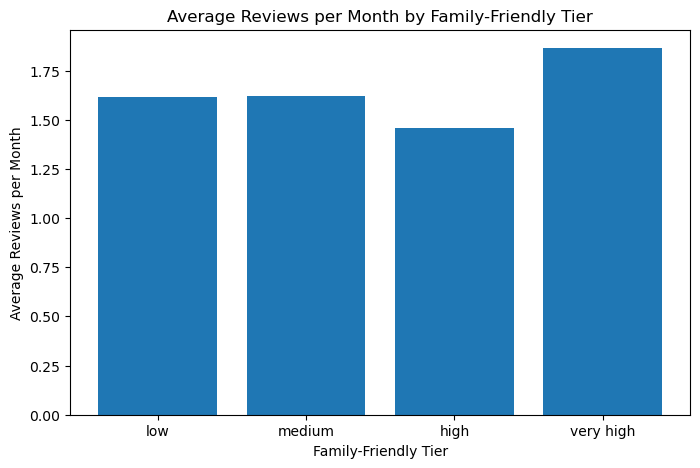

In [16]:
# plotting average demand by tier to see the broader relationship
plt.figure(figsize=(8, 5))
plt.bar(family_tier_summary['family_friendly_tier'], family_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Family-Friendly Tier')
plt.xlabel('Family-Friendly Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The family-friendly tiers show a clearer pattern than the individual score values. Low, medium, and high scoring listings have similar avg reviews per month, but the very high tier performs better. This suggests that one or two family-friendly features may not make a big difference on their own, but listings with a more complete set of family features may be better for demand.

The very high tier also has the highest average price, so this may overlap with larger or more premium listings. This score should be useful for host guidance, but I would say it's more of a product signal.

In [17]:
# comparing family-friendly demand by city to see if the pattern holds across markets
family_city_summary = (
    df.groupby(['city', 'family_friendly_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

family_city_summary.head()

,city,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,430,3.197302,2.455,113.406977
1,Asheville,medium,534,3.043577,2.500,125.904494
2,Asheville,high,1030,2.269786,1.740,169.155340
3,Asheville,very high,917,2.434656,2.080,212.371865
4,Austin,low,887,1.862909,1.040,138.588501


### Family-Friendly Lift by City

The overall family-friendly pattern looked promising, but city-level results might tell a different story. Since each market is different, I want to compare very high family-friendly listings against the average listing in the same city. This gives a better sense of where family-friendly features may actually stand out.

In [84]:
# calculating each city's average demand so family-friendly performance is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month')
)

# keeping all cities so no market disappears from the summary
all_cities = df[['city']].drop_duplicates()

# pulling only very high family-friendly listings to compare against each city average
very_high_family = (
    family_city_summary[family_city_summary['family_friendly_tier'] == 'very high']
    .copy()
)

# merging very high family-friendly results back to all cities
very_high_family = all_cities.merge(very_high_family, on='city', how='left')

# adding the city average so we can calculate lift
very_high_family = very_high_family.merge(city_avg_demand, on='city', how='left')

# filling missing counts for cities with no very high family-friendly listings
very_high_family['listing_count'] = very_high_family['listing_count'].fillna(0)

# calculating how much higher or lower very high family-friendly listings perform compared to the city average
very_high_family['family_demand_lift'] = (
    very_high_family['avg_reviews_per_month'] - very_high_family['city_avg_reviews_per_month']
)

# sorting values to see which cities have the highest family-friendly demand lift
very_high_family.sort_values('family_demand_lift', ascending=False).head(10)

,city,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,family_demand_lift
15,Newark,very high,155,2.210258,1.590,161.154839,1.754691,0.455567
30,Washington Dc,very high,1448,2.153798,1.720,225.980663,1.781329,0.372469
22,Salem,very high,84,2.228333,1.785,137.071429,1.903625,0.324708
17,NYC,very high,2987,1.462524,0.940,260.972548,1.170355,0.292169
23,Santa Clara,very high,953,1.534103,1.020,223.814271,1.252423,0.281680
11,Hawaii,very high,6127,1.559445,1.190,400.930308,1.281970,0.277475
19,Pacific Grove,very high,45,2.052889,1.530,341.155556,1.805549,0.247339
10,Fort Worth,very high,454,2.374824,2.170,169.367841,2.131796,0.243028
7,Columbus,very high,566,2.762562,2.300,150.178445,2.529595,0.232967
16,New Orleans,very high,1480,2.106223,1.870,280.625000,1.877803,0.228420


In [85]:
# sorting values to see which cities have the weakest family-friendly demand lift
very_high_family.sort_values('family_demand_lift').head(10)

,city,family_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,family_demand_lift
4,Cambridge,very high,152,1.214408,0.63,268.598684,1.467405,-0.252997
0,Asheville,very high,917,2.434656,2.08,212.371865,2.600677,-0.166020
20,Portland,very high,1361,2.365474,1.99,144.543718,2.404032,-0.038558
21,Rhode Island,very high,1084,1.364520,1.00,374.817343,1.393214,-0.028694
27,San Mateo,very high,657,1.852968,1.20,283.649924,1.820869,0.032099
8,Dallas,very high,1895,2.083789,1.62,192.094987,2.051684,0.032104
24,Santa Cruz,very high,455,2.083363,1.56,380.747253,2.033733,0.049630
3,Broward,very high,5651,1.729439,1.45,338.526986,1.670184,0.059255
12,Jersey City,very high,234,1.426581,0.87,249.927350,1.348709,0.077872
26,San Francisco,very high,1111,1.405302,0.74,301.865887,1.324608,0.080694


In [20]:
# checking the overall spread of family-friendly lift across cities
very_high_family['family_demand_lift'].describe()

count    31.000000
mean      0.143566
std       0.148811
min      -0.252997
25%       0.068563
50%       0.149088
75%       0.237997
max       0.455567
Name: family_demand_lift, dtype: float64

In [21]:
# flagging cities where very high family-friendly listings perform meaningfully above the city average
very_high_family['family_lift_group'] = pd.cut(
    very_high_family['family_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift'])

# sorting values to see which cities respond best to family-friendly features
family_lift_summary = (
    very_high_family[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'family_demand_lift', 'family_lift_group']
    ]
    .sort_values('family_demand_lift', ascending=False))

family_lift_summary.head(15)

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,family_demand_lift,family_lift_group
17,Newark,155,2.210258,1.754691,0.455567,strong lift
30,Washington Dc,1448,2.153798,1.781329,0.372469,strong lift
22,Salem,84,2.228333,1.903625,0.324708,strong lift
14,NYC,2987,1.462524,1.170355,0.292169,strong lift
26,Santa Clara,953,1.534103,1.252423,0.281680,strong lift
11,Hawaii,6127,1.559445,1.281970,0.277475,strong lift
19,Pacific Grove,45,2.052889,1.805549,0.247339,small lift
10,Fort Worth,454,2.374824,2.131796,0.243028,small lift
7,Columbus,566,2.762562,2.529595,0.232967,small lift
16,New Orleans,1480,2.106223,1.877803,0.228420,small lift


In [22]:
# counting cities by lift group to see how broadly the family-friendly signal applies
family_lift_summary['family_lift_group'].value_counts()

family_lift_group
small lift          21
strong lift          6
underperforming      4
very strong lift     0
Name: count, dtype: int64

### Family Friendly Lift Analysis: 

The family-friendly lift analysis shows that very high family-friendly listings perform above the city average in nearly every market, but the strength of that lift varies. A lift of 0.25 or more reviews per month was a more meaningful signal. Based on that cutoff, about half of the cities show strong or very strong lift, while the other half show only a smaller lift.

Overall, family-friendly features are useful, but they may be more valuable in certain markets like Washington DC, Salem, Santa Clara, Fort Worth, NYC, Clark County, Hawaii, Seattle, Columbus, and Austin. I would not treat this as a blanket recommendation for every host, but it could be useful for market-specific guidance.

### Work-Friendly Score

This score gives an idea about how well a listing is suited for remote work or longer stays. Features like workspace, wifi, self check-in, kitchen/laundry, private entrance, and long-term stay options would matter most for this type of guest. It's not a true identifier of work travel, but it could help identify listings that may be better positioned for remote workers, digital nomads, or guests staying longer than a quick weekend trip.

In [23]:
work_cols = [
    'amenity_workspace',
    'amenity_wifi',
    'amenity_self_checkin',
    'amenity_kitchen',
    'amenity_washer',
    'amenity_dryer',
    'amenity_private_entrance',
    'amenity_long_term_stays',
    'amenity_coffee_maker']

# checking how common each work-friendly feature is before creating the score
df[work_cols].sum().sort_values(ascending=False)

amenity_wifi                207785
amenity_kitchen             190055
amenity_coffee_maker        161866
amenity_washer              150989
amenity_dryer               145216
amenity_self_checkin        134260
amenity_workspace           110279
amenity_private_entrance    109033
amenity_long_term_stays     100347
dtype: int64

In [24]:
# creating a work-friendly score based on features that support remote work or longer stays
df['work_friendly_score'] = (
    df['amenity_workspace'] * 25 +
    df['amenity_long_term_stays'] * 20 +
    df['amenity_self_checkin'] * 15 +
    df['amenity_private_entrance'] * 10 +
    df['amenity_washer'] * 10 +
    df['amenity_dryer'] * 10 +
    df['amenity_coffee_maker'] * 5 +
    df['amenity_wifi'] * 3 +
    df['amenity_kitchen'] * 2)

In [25]:
# checking the score distribution before using it in later analysis
df['work_friendly_score'].describe()

count    210525.000000
mean         60.054578
std          26.520532
min           0.000000
25%          40.000000
50%          60.000000
75%          80.000000
max         100.000000
Name: work_friendly_score, dtype: float64

In [26]:
# sorting listings to see which ones score highest for work-friendly features
df[
    ['id', 'city', 'room_type', 'accommodates', 'bedrooms', 'bathrooms',
     'price', 'reviews_per_month', 'work_friendly_score']
].sort_values('work_friendly_score', ascending=False).head(10)

,id,city,room_type,accommodates,bedrooms,bathrooms,price,reviews_per_month,work_friendly_score
6,259576,Asheville,Entire home/apt,2,1.0,1.0,73.0,5.57,100
89639,53627124,Los Angeles,Private room,1,1.0,1.0,75.0,0.70,100
89641,820597082490386449,Los Angeles,Entire home/apt,6,3.0,2.0,184.0,2.00,100
89643,45878732,Los Angeles,Entire home/apt,1,1.0,1.0,125.0,0.18,100
210482,53683540,Washington Dc,Entire home/apt,6,3.0,3.0,372.0,0.27,100
89675,550644499981510129,Los Angeles,Entire home/apt,6,3.0,2.0,348.0,3.78,100
89590,52841891,Los Angeles,Entire home/apt,4,2.0,2.0,156.0,4.95,100
89596,761333046163532285,Los Angeles,Entire home/apt,10,4.0,4.0,350.0,1.00,100
89599,41745265,Los Angeles,Entire home/apt,4,2.0,2.0,169.0,0.12,100
89689,639067499889573021,Los Angeles,Entire home/apt,3,1.0,1.0,107.0,0.19,100


In [27]:
# grouping work-friendly scores into broader tiers so the pattern is easier to read
df['work_friendly_tier'] = pd.cut(
    df['work_friendly_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across work-friendly tiers
work_tier_summary = (
    df.groupby('work_friendly_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

work_tier_summary

,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,28479,0.943213,0.29,160.237403
1,medium,49388,1.447633,0.84,206.316069
2,high,71236,1.746470,1.17,220.381759
3,very high,61422,1.910038,1.44,240.636938


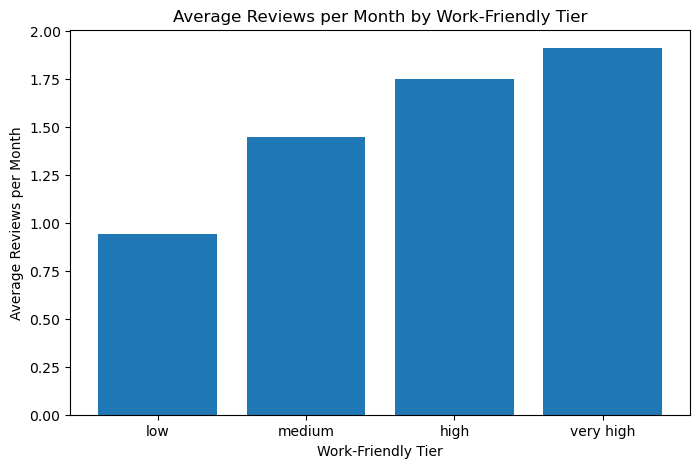

In [28]:
# plotting average demand by tier to see if work-friendly features show a broader pattern
plt.figure(figsize=(8, 5))
plt.bar(work_tier_summary['work_friendly_tier'], work_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Work-Friendly Tier')
plt.xlabel('Work-Friendly Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The work-friendly score shows a clearer pattern than the family-friendly score. Listings with stronger work-friendly features have higher average reviews per month, with demand increasing across each tier. This suggests that remote-work and longer-stay features may be broadly useful signals for listing performance.

This still does not prove that work-friendly amenities cause higher demand, but the pattern is strong enough to keep this score as a product feature. It could help identify listings that may be better positioned for remote workers, longer stays, or guests who want convenience and flexibility.

In [29]:
# comparing work-friendly demand by city to see if the pattern holds across markets
work_city_summary = (
    df.groupby(['city', 'work_friendly_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

work_city_summary.head()

,city,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,251,2.384502,1.400,133.382470
1,Asheville,medium,632,2.640459,2.070,148.900316
2,Asheville,high,1112,2.624505,2.140,173.764388
3,Asheville,very high,916,2.603537,2.145,179.217249
4,Austin,low,1398,0.591109,0.090,180.195279


In [30]:
# calculating each city's average demand so work-friendly performance is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month'))

# pulling only very high work-friendly listings to compare against each city average
very_high_work = work_city_summary[
    work_city_summary['work_friendly_tier'] == 'very high'].copy()

# adding the city average so we can calculate lift
very_high_work = very_high_work.merge(city_avg_demand, on='city', how='left')

# calculating how much higher or lower very high work-friendly listings perform compared to the city average
very_high_work['work_demand_lift'] = (
    very_high_work['avg_reviews_per_month'] - very_high_work['city_avg_reviews_per_month'])

# sorting values to see which cities have the highest work-friendly demand lift
very_high_work.sort_values('work_demand_lift', ascending=False).head(10)

,city,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,work_demand_lift
17,Newark,very high,253,2.429130,1.980,143.415020,1.754691,0.674440
14,NYC,very high,3370,1.638006,1.155,211.512463,1.170355,0.467651
1,Austin,very high,4175,1.984110,1.560,278.298683,1.566750,0.417361
21,Rhode Island,very high,897,1.691940,1.200,289.734671,1.393214,0.298726
10,Fort Worth,very high,571,2.424729,2.050,150.483363,2.131796,0.292932
13,Los Angeles,very high,8562,1.728709,1.120,252.212100,1.450240,0.278470
30,Washington Dc,very high,1937,2.025720,1.570,189.586474,1.781329,0.244391
29,Twin Cities,very high,1447,1.934457,1.450,166.657913,1.699577,0.234880
7,Columbus,very high,1042,2.763061,2.325,132.946257,2.529595,0.233466
19,Pacific Grove,very high,31,2.038710,1.400,266.935484,1.805549,0.233160


In [31]:
# sorting values to see which cities have the weakest work-friendly demand lift
very_high_work.sort_values('work_demand_lift').head(10)

,city,work_friendly_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,work_demand_lift
2,Bozeman,very high,225,1.896933,1.230,244.026667,1.982232,-0.085298
28,Seattle,very high,2318,2.123089,1.735,167.925798,2.135755,-0.012666
0,Asheville,very high,916,2.603537,2.145,179.217249,2.600677,0.002860
15,Nashville,very high,2624,2.328388,1.890,257.277058,2.304517,0.023871
23,San Diego,very high,3853,1.967070,1.490,299.440696,1.938483,0.028587
4,Cambridge,very high,179,1.514246,0.890,240.569832,1.467405,0.046841
9,Denver,very high,1821,2.029616,1.430,173.593081,1.978451,0.051165
18,Oakland,very high,673,1.495349,1.010,161.301634,1.442660,0.052690
22,Salem,very high,92,1.956413,1.390,121.434783,1.903625,0.052788
25,San Mateo,very high,930,1.886129,1.390,225.306452,1.820869,0.065260


In [32]:
# grouping work-friendly lift so I can see where this signal is strongest by market
very_high_work['work_lift_group'] = pd.cut(
    very_high_work['work_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift'])

# sorting values to see which cities respond best to work-friendly features
work_lift_summary = (
    very_high_work[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'work_demand_lift', 'work_lift_group']
    ]
    .sort_values('work_demand_lift', ascending=False))

work_lift_summary.head(15)

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,work_demand_lift,work_lift_group
17,Newark,253,2.429130,1.754691,0.674440,very strong lift
14,NYC,3370,1.638006,1.170355,0.467651,strong lift
1,Austin,4175,1.984110,1.566750,0.417361,strong lift
21,Rhode Island,897,1.691940,1.393214,0.298726,strong lift
10,Fort Worth,571,2.424729,2.131796,0.292932,strong lift
13,Los Angeles,8562,1.728709,1.450240,0.278470,strong lift
30,Washington Dc,1937,2.025720,1.781329,0.244391,small lift
29,Twin Cities,1447,1.934457,1.699577,0.234880,small lift
7,Columbus,1042,2.763061,2.529595,0.233466,small lift
19,Pacific Grove,31,2.038710,1.805549,0.233160,small lift


In [33]:
# counting cities by lift group to see how broadly the work-friendly signal applies
work_lift_summary['work_lift_group'].value_counts()

work_lift_group
small lift          23
strong lift          5
underperforming      2
very strong lift     1
Name: count, dtype: int64

The work-friendly lift analysis did better than the family-friendly analysis. Very high work friendly listings performed better than the city average in every market, with the top lift cities being Newark, Austin, and NYC. 

### Amenity Strength Score

This score gives an overall view of how well-equipped a listing is. Instead of focusing on one guest type, it looks at amenities that make a stay comfortable, easier, and convenient. Features like wifi, kitchen, self check-in, laundry, coffee maker, parking, air conditioning, heating, and basic supplies are standard expectations.

In [34]:
amenity_strength_cols = [
    'amenity_wifi',
    'amenity_kitchen',
    'amenity_self_checkin',
    'amenity_washer',
    'amenity_dryer',
    'amenity_coffee_maker',
    'amenity_parking_free',
    'amenity_air_conditioning',
    'amenity_heating',
    'amenity_cleaning_supplies',
    'amenity_essentials',
    'amenity_hot_water',
    'amenity_hangers',
    'amenity_iron']

# checking how common each practical amenity is before creating the broader amenity strength score
df[amenity_strength_cols].sum().sort_values(ascending=False)

amenity_wifi                 207785
amenity_essentials           192988
amenity_kitchen              190055
amenity_air_conditioning     176635
amenity_hangers              176283
amenity_heating              171022
amenity_hot_water            169720
amenity_parking_free         167371
amenity_iron                 166166
amenity_coffee_maker         161866
amenity_washer               150989
amenity_dryer                145216
amenity_self_checkin         134260
amenity_cleaning_supplies     80135
dtype: int64

In [35]:
# creating a broader amenity strength score based on practical features that make a stay feel complete
df['amenity_strength_score'] = (
    df['amenity_self_checkin'] * 15 +
    df['amenity_cleaning_supplies'] * 15 +
    df['amenity_parking_free'] * 10 +
    df['amenity_coffee_maker'] * 10 +
    df['amenity_washer'] * 10 +
    df['amenity_dryer'] * 10 +
    df['amenity_kitchen'] * 7 +
    df['amenity_air_conditioning'] * 7 +
    df['amenity_heating'] * 5 +
    df['amenity_hot_water'] * 4 +
    df['amenity_essentials'] * 3 +
    df['amenity_wifi'] * 2 +
    df['amenity_hangers'] * 1 +
    df['amenity_iron'] * 1)

In [36]:
# checking the score distribution before using it in later analysis
df['amenity_strength_score'].describe()

count    210525.000000
mean         70.814146
std          21.660650
min           0.000000
25%          57.000000
50%          75.000000
75%          85.000000
max         100.000000
Name: amenity_strength_score, dtype: float64

In [37]:
# grouping amenity strength scores into broader tiers so the pattern is easier to read
df['amenity_strength_tier'] = pd.cut(
    df['amenity_strength_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

In [38]:
# comparing demand and price across amenity strength tiers
amenity_tier_summary = (
    df.groupby('amenity_strength_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

amenity_tier_summary

,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,7313,0.782556,0.21,141.619035
1,medium,31922,1.154433,0.49,173.296473
2,high,73780,1.489784,0.85,209.283261
3,very high,97510,1.923868,1.48,238.169490


In [39]:
# comparing amenity strength by city to see if the pattern holds across markets
amenity_city_summary = (
    df.groupby(['city', 'amenity_strength_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

amenity_city_summary.head()

,city,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,29,1.500690,1.10,81.344828
1,Asheville,medium,231,2.408009,1.49,146.116883
2,Asheville,high,1014,2.804073,2.21,147.296844
3,Asheville,very high,1637,2.521362,2.09,182.957850
4,Austin,low,90,0.838444,0.10,151.577778


In [40]:
# calculating each city's average demand so amenity strength is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month'))

# pulling very high amenity strength listings to compare against each city average
very_high_amenity = amenity_city_summary[
    amenity_city_summary['amenity_strength_tier'] == 'very high'].copy()

# adding the city average so we can calculate lift
very_high_amenity = very_high_amenity.merge(city_avg_demand, on='city', how='left')

# calculating how much higher or lower very high amenity listings perform compared to the city average
very_high_amenity['amenity_demand_lift'] = (
    very_high_amenity['avg_reviews_per_month'] - very_high_amenity['city_avg_reviews_per_month'])

# sorting values to see which cities have the highest amenity strength lift
very_high_amenity.sort_values('amenity_demand_lift', ascending=False).head(10)

,city,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,amenity_demand_lift
14,NYC,very high,6727,1.786707,1.34,193.353204,1.170355,0.616352
17,Newark,very high,401,2.248529,1.68,145.613466,1.754691,0.493838
30,Washington Dc,very high,2399,2.126103,1.68,190.887870,1.781329,0.344773
13,Los Angeles,very high,13745,1.739295,1.15,245.242270,1.450240,0.289055
1,Austin,very high,6364,1.848086,1.39,283.964016,1.566750,0.281337
11,Hawaii,very high,8942,1.555900,1.16,355.406956,1.281970,0.273930
2,Bozeman,very high,328,2.228963,1.73,225.378049,1.982232,0.246732
3,Broward,very high,6946,1.888033,1.58,288.656061,1.670184,0.217849
24,San Francisco,very high,1790,1.523860,0.74,253.610615,1.324608,0.199253
5,Chicago,very high,3272,1.984147,1.75,173.763142,1.791056,0.193091


In [41]:
# sorting values to see which cities have the weakest amenity strength lift
very_high_amenity.sort_values('amenity_demand_lift').head(10)

,city,amenity_strength_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,amenity_demand_lift
0,Asheville,very high,1637,2.521362,2.090,182.957850,2.600677,-0.079314
4,Cambridge,very high,230,1.395087,0.800,245.400000,1.467405,-0.072318
27,Santa Cruz,very high,708,1.963390,1.325,369.266949,2.033733,-0.070343
19,Pacific Grove,very high,54,1.758148,1.185,320.888889,1.805549,-0.047401
12,Jersey City,very high,469,1.404136,0.960,188.059701,1.348709,0.055427
25,San Mateo,very high,1299,1.880731,1.420,237.543495,1.820869,0.059862
9,Denver,very high,2828,2.047221,1.490,169.179632,1.978451,0.068770
18,Oakland,very high,941,1.512370,1.000,165.759830,1.442660,0.069710
8,Dallas,very high,3490,2.124418,1.705,170.002579,2.051684,0.072734
20,Portland,very high,2520,2.488881,2.000,130.313492,2.404032,0.084849


In [42]:
# grouping amenity strength lift so I can see where this signal is strongest by market
very_high_amenity['amenity_lift_group'] = pd.cut(
    very_high_amenity['amenity_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift'])

# sorting values to see which cities respond best to very high amenity strength
amenity_lift_summary = (
    very_high_amenity[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'amenity_demand_lift', 'amenity_lift_group']]
    .sort_values('amenity_demand_lift', ascending=False))

amenity_lift_summary.head()

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,amenity_demand_lift,amenity_lift_group
14,NYC,6727,1.786707,1.170355,0.616352,very strong lift
17,Newark,401,2.248529,1.754691,0.493838,strong lift
30,Washington Dc,2399,2.126103,1.781329,0.344773,strong lift
13,Los Angeles,13745,1.739295,1.450240,0.289055,strong lift
1,Austin,6364,1.848086,1.566750,0.281337,strong lift


In [43]:
# counting cities by lift group to see how broadly amenity strength applies
amenity_lift_summary['amenity_lift_group'].value_counts()

amenity_lift_group
small lift          21
strong lift          5
underperforming      4
very strong lift     1
Name: count, dtype: int64

The amenity strength score did OK, but didn't perform as well as the work amenity score. Listings with very high strenth did perform above the city average. 

### Host Quality Score

This score gives an idea about how strong a listing’s host and trust signals are. Features like Superhost status, response time, instant booking, and review score signal trust for renters. This is not a perfect measure of host quality, but it gives an idea of how reliable the host is. 

In [44]:
host_cols = [
    'host_is_superhost',
    'host_response_time_ord',
    'instant_bookable',
    'review_scores_rating']

# checking the host-related fields before creating the host quality score
df[host_cols].describe()

,host_is_superhost,host_response_time_ord,instant_bookable,review_scores_rating
count,210525.000000,210525.000000,210525.000000,210525.000000
mean,0.417746,2.186301,0.317915,4.732237
std,0.493189,1.443501,0.465667,0.521867
min,0.000000,-1.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,4.680000
50%,0.000000,3.000000,0.000000,4.880000
75%,1.000000,3.000000,1.000000,5.000000
max,1.000000,3.000000,1.000000,5.000000


In [45]:
# creating a cleaner response time field so missing values do not lower the host quality score unfairly
df['host_response_score'] = df['host_response_time_ord'].replace(-1, 0)

In [46]:
# creating a host quality score based on trust signals guests may use before booking
df['host_quality_score'] = (
    df['host_is_superhost'] * 25 +
    df['instant_bookable'] * 15 +
    df['host_response_score'] / 3 * 25 +
    df['review_scores_rating'] / 5 * 35)

In [47]:
# checking the score distribution before using it in later analysis
df['host_quality_score'].describe()

count    210525.000000
mean         67.798785
std          20.583695
min           0.000000
25%          55.310000
50%          71.990000
75%          84.370000
max         100.000000
Name: host_quality_score, dtype: float64

In [48]:
# grouping host quality scores into broader tiers so the pattern is easier to read
df['host_quality_tier'] = pd.cut(
    df['host_quality_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across host quality tiers
host_tier_summary = (
    df.groupby('host_quality_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

host_tier_summary

,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,1944,0.074877,0.03,166.663066
1,medium,40982,0.642744,0.26,189.601801
2,high,85872,1.533398,1.00,213.645763
3,very high,81727,2.226007,1.82,229.936410


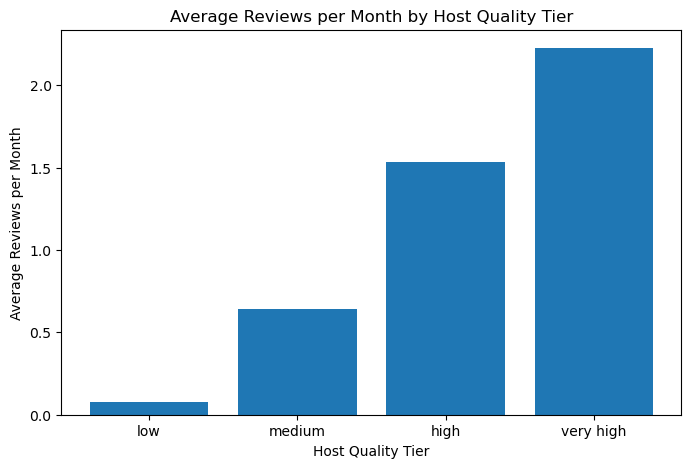

In [49]:
# plotting average demand by tier to see if stronger host signals are tied to demand
plt.figure(figsize=(8, 5))
plt.bar(host_tier_summary['host_quality_tier'], host_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Host Quality Tier')
plt.xlabel('Host Quality Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The host quality score shows the strongest demand pattern so far. Listings in the very high host quality tier have much higher average and median reviews per month than the lower tiers. What I think is really interesting is that they're not the most expensive, meaning they're more seasoned and don't need to rely on high prices since they get more consistent demand OR they have smaller/more rentable listings that are more consistently booked out.

This score should be interpreted carefully because review score is part of the host quality score, and listings with few or no reviews may naturally fall into lower tiers. Either way, the pattern supports the idea that Superhost status, response behavior, instant booking, and strong ratings can help listings feel more reliable to renters.

In [50]:
# comparing host quality by city to see if the pattern holds across markets
host_city_summary = (
    df.groupby(['city', 'host_quality_tier'])
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price', 'mean'))
    .reset_index())

host_city_summary.head()

,city,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,Asheville,low,3,0.180000,0.220,416.666667
1,Asheville,medium,330,1.162394,0.665,172.936364
2,Asheville,high,676,1.994290,1.480,163.658284
3,Asheville,very high,1902,3.069558,2.590,166.151945
4,Austin,low,135,0.059852,0.030,194.651852


In [51]:
# calculating each city's average demand so host quality is compared within the same market
city_avg_demand = (
    df.groupby('city')['reviews_per_month']
    .mean()
    .reset_index(name='city_avg_reviews_per_month'))

# pulling very high host quality listings to compare against each city average
very_high_host = host_city_summary[
    host_city_summary['host_quality_tier'] == 'very high'
].copy()

# adding the city average so we can calculate lift
very_high_host = very_high_host.merge(city_avg_demand, on='city', how='left')

# calculating how much higher or lower very high host quality listings perform compared to the city average
very_high_host['host_demand_lift'] = (
    very_high_host['avg_reviews_per_month'] - very_high_host['city_avg_reviews_per_month'])

# sorting values to see which cities have the highest host quality lift
very_high_host.sort_values('host_demand_lift', ascending=False).head(10)

,city,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,host_demand_lift
27,Santa Cruz,very high,675,2.953778,2.470,277.622222,2.033733,0.920045
17,Newark,very high,233,2.645279,2.370,123.115880,1.754691,0.890588
30,Washington Dc,very high,1735,2.667262,2.300,193.133718,1.781329,0.885933
14,NYC,very high,7453,2.012131,1.620,174.551053,1.170355,0.841776
12,Jersey City,very high,278,2.168813,1.895,134.550360,1.348709,0.820104
1,Austin,very high,4255,2.320068,1.890,265.855229,1.566750,0.753319
8,Dallas,very high,1622,2.758397,2.300,188.081998,2.051684,0.706713
18,Oakland,very high,795,2.130013,1.710,142.628931,1.442660,0.687353
13,Los Angeles,very high,10848,2.103579,1.600,220.419801,1.450240,0.653340
25,San Mateo,very high,1115,2.425740,2.000,216.859193,1.820869,0.604871


In [52]:
# sorting values to see which cities have the weakest lift
very_high_host.sort_values('host_demand_lift').head(10)

,city,host_quality_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,city_avg_reviews_per_month,host_demand_lift
7,Columbus,very high,1042,2.769578,2.405,135.611324,2.529595,0.239983
6,Clark County,very high,4307,2.234634,1.890,211.410495,1.940451,0.294183
2,Bozeman,very high,289,2.286644,1.900,227.235294,1.982232,0.304412
29,Twin Cities,very high,1912,2.064901,1.670,158.558054,1.699577,0.365323
15,Nashville,very high,3895,2.685512,2.310,256.205648,2.304517,0.380995
16,New Orleans,very high,2690,2.274952,2.010,231.356134,1.877803,0.397148
11,Hawaii,very high,10431,1.688398,1.250,366.489790,1.281970,0.406428
3,Broward,very high,4990,2.079966,1.790,289.655711,1.670184,0.409781
5,Chicago,very high,2501,2.202279,1.990,173.318673,1.791056,0.411223
22,Salem,very high,148,2.330676,1.660,112.229730,1.903625,0.427051


In [53]:
# grouping host quality lift so I can see where this signal is strongest by market
very_high_host['host_lift_group'] = pd.cut(
    very_high_host['host_demand_lift'],
    bins=[-1, 0, 0.25, 0.5, 1.5],
    labels=['underperforming', 'small lift', 'strong lift', 'very strong lift']
)

# sorting values to see which cities respond best to very high host quality
host_lift_summary = (
    very_high_host[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'host_demand_lift', 'host_lift_group']
    ]
    .sort_values('host_demand_lift', ascending=False)
)

host_lift_summary.head(15)

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,host_demand_lift,host_lift_group
27,Santa Cruz,675,2.953778,2.033733,0.920045,very strong lift
17,Newark,233,2.645279,1.754691,0.890588,very strong lift
30,Washington Dc,1735,2.667262,1.781329,0.885933,very strong lift
14,NYC,7453,2.012131,1.170355,0.841776,very strong lift
12,Jersey City,278,2.168813,1.348709,0.820104,very strong lift
1,Austin,4255,2.320068,1.566750,0.753319,very strong lift
8,Dallas,1622,2.758397,2.051684,0.706713,very strong lift
18,Oakland,795,2.130013,1.442660,0.687353,very strong lift
13,Los Angeles,10848,2.103579,1.450240,0.653340,very strong lift
25,San Mateo,1115,2.425740,1.820869,0.604871,very strong lift


In [54]:
# counting cities by lift group to see how broadly host quality applies
host_lift_summary['host_lift_group'].value_counts()

host_lift_group
very strong lift    17
strong lift         13
small lift           1
underperforming      0
Name: count, dtype: int64

In [55]:
# checking the spread of host quality lift before setting better lift groups
very_high_host['host_demand_lift'].describe()

count    31.000000
mean      0.555899
std       0.185462
min       0.239983
25%       0.410502
50%       0.556163
75%       0.670346
max       0.920045
Name: host_demand_lift, dtype: float64

In [56]:
# grouping host quality lift with wider bins because this signal is much stronger than the other scores
very_high_host['host_lift_group'] = pd.cut(
    very_high_host['host_demand_lift'],
    bins=[-1, 0.25, 0.75, 1.25, 2],
    labels=['small lift', 'strong lift', 'very strong lift', 'exceptional lift'])

# rebuilding the host lift summary with the updated groups
host_lift_summary = (
    very_high_host[
        ['city', 'listing_count', 'avg_reviews_per_month', 'city_avg_reviews_per_month',
         'host_demand_lift', 'host_lift_group']
    ]
    .sort_values('host_demand_lift', ascending=False))

host_lift_summary.head(15)

,city,listing_count,avg_reviews_per_month,city_avg_reviews_per_month,host_demand_lift,host_lift_group
27,Santa Cruz,675,2.953778,2.033733,0.920045,very strong lift
17,Newark,233,2.645279,1.754691,0.890588,very strong lift
30,Washington Dc,1735,2.667262,1.781329,0.885933,very strong lift
14,NYC,7453,2.012131,1.170355,0.841776,very strong lift
12,Jersey City,278,2.168813,1.348709,0.820104,very strong lift
1,Austin,4255,2.320068,1.566750,0.753319,very strong lift
8,Dallas,1622,2.758397,2.051684,0.706713,strong lift
18,Oakland,795,2.130013,1.442660,0.687353,strong lift
13,Los Angeles,10848,2.103579,1.450240,0.653340,strong lift
25,San Mateo,1115,2.425740,1.820869,0.604871,strong lift


In [57]:
# counting cities by updated host lift group
host_lift_summary['host_lift_group'].value_counts()

host_lift_group
strong lift         24
very strong lift     6
small lift           1
exceptional lift     0
Name: count, dtype: int64

Host quality shows the most consistent lift across the board. Every city shows at least strong lift for very high host quality listings, and most cities fall into the very strong lift group. It shows that host trust signals matter across markets more consistently than guest-type scores like family-friendly or work-friendly.

### Pricing Competitiveness Score

This score gives an idea about whether a listing is priced competitively compared to similar listings in the same market. Instead of comparing every listing against the full dataset, I’m comparing listings by city, room type, and capacity. This gives a more realistic peer group because price expectations are different across markets and listing types (ie: A Denver condo can't be compared to a full house in Hawaii).

In [58]:
# removing old peer pricing columns before rerunning this cell
peer_cols = ['capacity_group', 'peer_median_price', 'price_vs_peer']
df = df.drop(columns=[col for col in peer_cols if col in df.columns])

# creating capacity groups so listings are compared against similar-sized listings
df['capacity_group'] = pd.cut(
    df['accommodates'],
    bins=[0, 2, 4, 6, 20],
    labels=['1-2 guests', '3-4 guests', '5-6 guests', '7+ guests'])

# calculating the median peer price by city, room type, and capacity group
peer_price = (
    df.groupby(['city', 'room_type', 'capacity_group'], observed=False)['price']
    .median()
    .reset_index(name='peer_median_price'))

# adding the peer median price back to the main dataframe
df = df.merge(
    peer_price,
    on=['city', 'room_type', 'capacity_group'],
    how='left')

# calculating how far each listing's price is from its peer median
df['price_vs_peer'] = (
    (df['price'] - df['peer_median_price']) / df['peer_median_price'])

df[['city', 'room_type', 'capacity_group', 'price', 'peer_median_price', 'price_vs_peer']].head()

,city,room_type,capacity_group,price,peer_median_price,price_vs_peer
0,Asheville,Entire home/apt,1-2 guests,100.0,98.0,0.020408
1,Asheville,Entire home/apt,1-2 guests,100.0,98.0,0.020408
2,Asheville,Private room,1-2 guests,66.0,75.0,-0.120000
3,Asheville,Private room,1-2 guests,45.0,75.0,-0.400000
4,Asheville,Entire home/apt,3-4 guests,100.0,124.0,-0.193548


In [59]:
# checking the pricing comparison fields before creating the score
df[['price', 'peer_median_price', 'price_vs_peer']].describe()

C:\Users\cococ\miniconda3\envs\ds\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,price,peer_median_price,price_vs_peer
count,210525.000000,210495.000000,2.104900e+05
mean,214.855509,178.833321,inf
std,211.986930,108.861973,NaN
min,0.000000,0.000000,-1.000000e+00
25%,95.000000,105.500000,-2.583333e-01
50%,150.000000,156.000000,0.000000e+00
75%,253.000000,240.000000,3.899483e-01
max,2000.000000,1941.000000,inf


In [60]:
# replacing zero prices with missing values so they do not distort peer pricing comparisons
df['price_clean'] = df['price'].replace(0, np.nan)

In [61]:
# recalculating peer median price using the cleaned price field
peer_price = (
    df.groupby(['city', 'room_type', 'capacity_group'])['price_clean']
    .median()
    .reset_index(name='peer_median_price'))

# dropping the earlier peer price columns before merging the corrected version
df = df.drop(columns=['peer_median_price', 'price_vs_peer'], errors='ignore')

# adding the corrected peer median price back to the main dataframe
df = df.merge(
    peer_price,
    on=['city', 'room_type', 'capacity_group'],
    how='left')

# calculating how far each listing's price is from its peer median
df['price_vs_peer'] = (
    (df['price_clean'] - df['peer_median_price']) / df['peer_median_price'])

In [62]:
# checking the pricing comparison fields after removing zero-price distortion
df[['price_clean', 'peer_median_price', 'price_vs_peer']].describe()

,price_clean,peer_median_price,price_vs_peer
count,210477.000000,210494.000000,210477.000000
mean,214.904507,178.848920,0.202616
std,211.986266,108.866632,0.868748
min,1.000000,22.000000,-0.995614
25%,95.000000,105.500000,-0.258333
50%,150.000000,156.000000,0.000000
75%,253.000000,240.000000,0.389877
max,2000.000000,1941.000000,35.363636


In [63]:
# capping extreme price differences so one outlier does not distort the pricing score
df['price_vs_peer_capped'] = df['price_vs_peer'].clip(lower=-1, upper=2)

In [64]:
# creating a pricing competitiveness score where listings closer to or below peer median score higher
df['pricing_competitiveness_score'] = (
    100 - (df['price_vs_peer_capped'].abs() * 100)).clip(lower=0, upper=100)

In [65]:
# checking the score distribution before using it in later analysis
df['pricing_competitiveness_score'].describe()

count    210477.000000
mean         62.579991
std          29.461788
min           0.000000
25%          48.101266
50%          70.000000
75%          85.714286
max         100.000000
Name: pricing_competitiveness_score, dtype: float64

In [66]:
# grouping pricing competitiveness scores into broader tiers so the pattern is easier to read
df['pricing_competitiveness_tier'] = pd.cut(
    df['pricing_competitiveness_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across pricing competitiveness tiers
pricing_tier_summary = (
    df.groupby('pricing_competitiveness_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_peer_price=('peer_median_price', 'mean'))
    .reset_index())

pricing_tier_summary

,pricing_competitiveness_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_peer_price
0,low,30118,1.165668,0.63,493.992529,192.824059
1,medium,26268,1.500638,0.93,200.863103,197.781122
2,high,65659,1.671147,1.05,158.484534,177.184636
3,very high,88432,1.760456,1.19,165.914839,169.690796


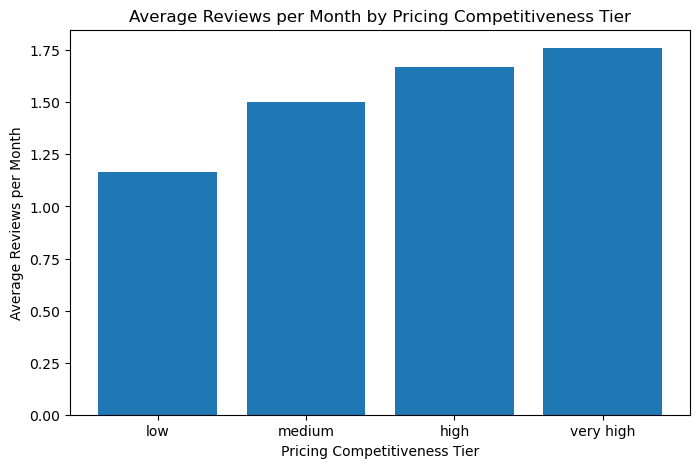

In [67]:
# plotting average demand by pricing tier to see if competitive pricing is tied to higher demand
plt.figure(figsize=(8, 5))
plt.bar(pricing_tier_summary['pricing_competitiveness_tier'], pricing_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Pricing Competitiveness Tier')
plt.xlabel('Pricing Competitiveness Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

This shows that over pricing might hurt bookings. 

Listings that are priced closer to similar listings in the same city, room type, and capacity group have higher average reviews per month. 

This does not mean the cheapest listings always perform best. The score is based on closeness to the peer median, not low price alone. This makes it more useful for host guidance because it compares each listing to a realistic local benchmark.

In [68]:
# summarizing all product scores to compare how each one relates to demand and price
score_summary = pd.DataFrame({
    'score': [
        'family_friendly_score',
        'work_friendly_score',
        'amenity_strength_score',
        'host_quality_score',
        'pricing_competitiveness_score'
    ],
    'avg_score': [
        df['family_friendly_score'].mean(),
        df['work_friendly_score'].mean(),
        df['amenity_strength_score'].mean(),
        df['host_quality_score'].mean(),
        df['pricing_competitiveness_score'].mean()
    ],
    'median_score': [
        df['family_friendly_score'].median(),
        df['work_friendly_score'].median(),
        df['amenity_strength_score'].median(),
        df['host_quality_score'].median(),
        df['pricing_competitiveness_score'].median()
    ],
    'correlation_with_reviews_per_month': [
        df['family_friendly_score'].corr(df['reviews_per_month']),
        df['work_friendly_score'].corr(df['reviews_per_month']),
        df['amenity_strength_score'].corr(df['reviews_per_month']),
        df['host_quality_score'].corr(df['reviews_per_month']),
        df['pricing_competitiveness_score'].corr(df['reviews_per_month'])
    ],
    'correlation_with_price': [
        df['family_friendly_score'].corr(df['price_clean']),
        df['work_friendly_score'].corr(df['price_clean']),
        df['amenity_strength_score'].corr(df['price_clean']),
        df['host_quality_score'].corr(df['price_clean']),
        df['pricing_competitiveness_score'].corr(df['price_clean'])
    ]})

score_summary.sort_values('correlation_with_reviews_per_month', ascending=False)

,score,avg_score,median_score,correlation_with_reviews_per_month,correlation_with_price
3,host_quality_score,67.798785,71.99,0.324111,0.095730
2,amenity_strength_score,70.814146,75.00,0.184434,0.122930
1,work_friendly_score,60.054578,60.00,0.147986,0.112994
4,pricing_competitiveness_score,62.579991,70.00,0.106582,-0.476156
0,family_friendly_score,60.741171,65.00,0.050767,0.286763


### Product Score Summary

The score summary helps compare which product signals are most closely associated with demand. Host quality has the strongest relationship with reviews per month, followed by amenity strength, work-friendly features, pricing competitiveness, and family-friendly features.

It shows trust and reliability might matter more consistently than guest-type positioning alone. Practical amenities and work-friendly features impact demand, while family-friendly features seem more market-specific. The pricing competitiveness score shows that listings perform better when their price is close to similar listings in the same market; they'll perform better and make more sense for guests.

In [69]:
# creating one combined product score from the main host, amenity, pricing, and guest-fit signals
df['listing_product_score'] = (
    df['host_quality_score'] * 0.35 +
    df['amenity_strength_score'] * 0.25 +
    df['pricing_competitiveness_score'] * 0.20 +
    df['work_friendly_score'] * 0.10 +
    df['family_friendly_score'] * 0.10)

In [70]:
# checking the combined product score before using it for segments or final recommendations
df['listing_product_score'].describe()

count    210477.000000
mean         66.034339
std          15.173707
min           0.000000
25%          56.059000
50%          67.568182
75%          77.311405
max         100.000000
Name: listing_product_score, dtype: float64

In [71]:
# grouping the combined product score into tiers so it can be used for recommendations
df['listing_product_tier'] = pd.cut(
    df['listing_product_score'],
    bins=[-1, 25, 50, 75, 100],
    labels=['low', 'medium', 'high', 'very high'])

# comparing demand and price across the combined product score tiers
product_tier_summary = (
    df.groupby('listing_product_tier')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'))
    .reset_index())

product_tier_summary

,listing_product_tier,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price
0,low,1171,0.181776,0.04,259.044406
1,medium,31985,0.713457,0.25,212.415101
2,high,112923,1.538119,0.98,222.816663
3,very high,64398,2.223843,1.87,201.464207


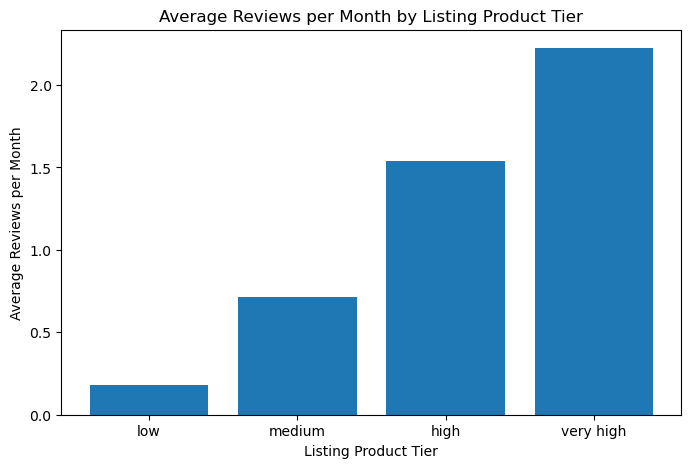

In [72]:
# plotting average demand by product tier to see if the combined score gives a useful ranking
plt.figure(figsize=(8, 5))
plt.bar(product_tier_summary['listing_product_tier'], product_tier_summary['avg_reviews_per_month'])
plt.title('Average Reviews per Month by Listing Product Tier')
plt.xlabel('Listing Product Tier')
plt.ylabel('Average Reviews per Month')
plt.show()

The combined product score has a pretty clear pattern. Listings with higher scores also tend to have more reviews per month. The very high tier performs the best, which tells me this score is probably capturing some useful demand.

The score combines host quality, amenities, pricing, work-friendly features, and family-friendly features, so I would use it more as a guide. It helps compare listings and gives a starting point for where hosts might improve.

### Listing Segments

After creating the product scores, I want to see whether listings group into different product types.

This is different from prediction. I am not using reviews per month to create the clusters. I am only using the product scores, then comparing demand after the segments are created.

Note: KMeans cluster numbers do not have built-in meaning. Segment 0, 1, 2, or 3 are just labels from the algorithm. I need to review the average scores for each cluster before naming the segments.

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# using the individual product scores for clustering
segment_cols = [
    'family_friendly_score',
    'work_friendly_score',
    'amenity_strength_score',
    'host_quality_score',
    'pricing_competitiveness_score']

# dropping rows with missing score values before clustering
segment_df = df[segment_cols].dropna().copy()

# scaling scores so each score contributes more evenly
scaler = StandardScaler()
segment_scaled = scaler.fit_transform(segment_df)

In [74]:
# testing a few cluster counts to see where the improvement starts to slow down
inertia = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(segment_scaled)
    inertia.append(kmeans.inertia_)

# saving the elbow results in a dataframe so they are easier to read
elbow_df = pd.DataFrame({
    'k': range(2, 7),
    'inertia': inertia
})

elbow_df

,k,inertia
0,2,680662.182747
1,3,574799.228460
2,4,494518.443656
3,5,439176.469925
4,6,400159.719169


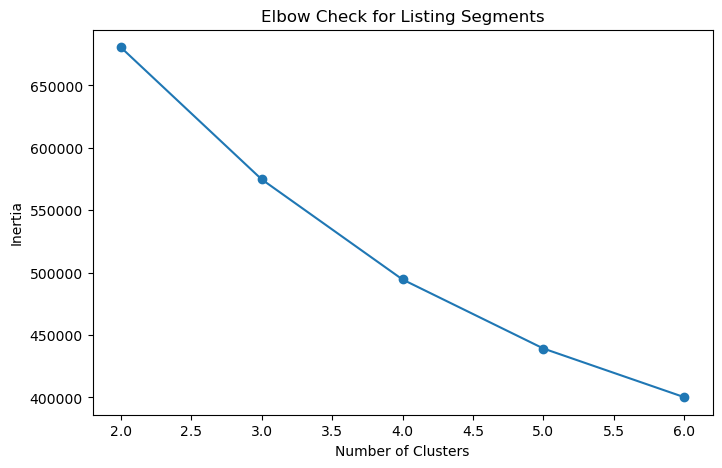

In [75]:
# plotting the elbow curve to help choose a reasonable number of listing segments
plt.figure(figsize=(8, 5))
plt.plot(elbow_df['k'], elbow_df['inertia'], marker='o')
plt.title('Elbow Check for Listing Segments')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

There isn't an obvious elbow, so this is just exploratory. I chose 4 clusters because it gives enough separation to compare different listing types without creating too many groups to explain clearly.

In [76]:
# creating 4 listing segments based on the product score patterns
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
segment_df['listing_segment'] = kmeans.fit_predict(segment_scaled)

# adding the segment labels back to the main dataframe
df.loc[segment_df.index, 'listing_segment'] = segment_df['listing_segment']

In [77]:
# comparing average score patterns across each listing segment
segment_summary = (
    df.groupby('listing_segment')
    .agg(
        listing_count=('id', 'count'),
        avg_reviews_per_month=('reviews_per_month', 'mean'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_family_score=('family_friendly_score', 'mean'),
        avg_work_score=('work_friendly_score', 'mean'),
        avg_amenity_score=('amenity_strength_score', 'mean'),
        avg_host_score=('host_quality_score', 'mean'),
        avg_pricing_score=('pricing_competitiveness_score', 'mean'),
        avg_product_score=('listing_product_score', 'mean'))
    .reset_index()
    .sort_values('avg_product_score', ascending=False))

segment_summary

,listing_segment,listing_count,avg_reviews_per_month,median_reviews_per_month,avg_price,avg_family_score,avg_work_score,avg_amenity_score,avg_host_score,avg_pricing_score,avg_product_score
0,0.0,67300,2.019629,1.62,197.589004,82.675260,83.632125,90.081426,75.648964,75.122493,80.652731
3,3.0,67705,1.758389,1.13,154.562381,52.586072,54.868400,67.647869,69.821304,75.984053,67.291682
1,1.0,32898,1.295107,0.79,454.907654,72.158946,67.733114,78.204936,69.456054,13.130371,60.476133
2,2.0,42574,0.994824,0.36,152.781463,30.253559,25.141894,39.728684,50.914539,59.647710,45.221347


The segment summary is the step that tells me what each cluster actually means.

Since KMeans gives random segment numbers, I should not name the clusters until I compare the average product scores, pricing scores, amenity scores, host scores, and demand levels.

The strongest segment should be the one with the highest overall product score. A weaker segment should have lower product scores. If a segment has a high price but weak pricing competitiveness, it might represent listings that look premium but may be priced too far above similar local listings.

In [78]:
# naming segments based on their score patterns instead of assuming the cluster numbers mean something
summary_sorted = segment_summary.sort_values('avg_product_score', ascending=False).reset_index(drop=True)

segment_names = {}

for i, row in summary_sorted.iterrows():
    segment = row['listing_segment']
    
    if i == 0:
        name = 'strong_all_around'
    elif row['avg_price'] == segment_summary['avg_price'].max() and row['avg_pricing_score'] < segment_summary['avg_pricing_score'].median():
        name = 'premium_but_less_price_competitive'
    elif row['avg_product_score'] < segment_summary['avg_product_score'].median():
        name = 'weaker_product_signal'
    else:
        name = 'standard_mid_market'

    segment_names[segment] = name

df['listing_segment_name'] = df['listing_segment'].map(segment_names)

segment_names

{np.float64(0.0): 'strong_all_around',
 np.float64(3.0): 'standard_mid_market',
 np.float64(1.0): 'premium_but_less_price_competitive',
 np.float64(2.0): 'weaker_product_signal'}

In [79]:
# checking whether the segment names now match the actual score patterns
segment_named_summary = (
    df.groupby(['listing_segment', 'listing_segment_name'])
    .agg(
        listing_count=('id', 'count'),
        median_reviews_per_month=('reviews_per_month', 'median'),
        avg_price=('price_clean', 'mean'),
        avg_family_score=('family_friendly_score', 'mean'),
        avg_work_score=('work_friendly_score', 'mean'),
        avg_amenity_score=('amenity_strength_score', 'mean'),
        avg_host_score=('host_quality_score', 'mean'),
        avg_pricing_score=('pricing_competitiveness_score', 'mean'),
        avg_product_score=('listing_product_score', 'mean'))
    .reset_index()
    .sort_values('avg_product_score', ascending=False))

segment_named_summary

,listing_segment,listing_segment_name,listing_count,median_reviews_per_month,avg_price,avg_family_score,avg_work_score,avg_amenity_score,avg_host_score,avg_pricing_score,avg_product_score
0,0.0,strong_all_around,67300,1.62,197.589004,82.675260,83.632125,90.081426,75.648964,75.122493,80.652731
3,3.0,standard_mid_market,67705,1.13,154.562381,52.586072,54.868400,67.647869,69.821304,75.984053,67.291682
1,1.0,premium_but_less_price_competitive,32898,0.79,454.907654,72.158946,67.733114,78.204936,69.456054,13.130371,60.476133
2,2.0,weaker_product_signal,42574,0.36,152.781463,30.253559,25.141894,39.728684,50.914539,59.647710,45.221347


In [80]:
# checking how many listings fall into each named segment
df['listing_segment_name'].value_counts()

listing_segment_name
standard_mid_market                   67705
strong_all_around                     67300
weaker_product_signal                 42574
premium_but_less_price_competitive    32898
Name: count, dtype: int64

In [94]:
# saving the final product feature dataset for final modeling and recommendations
df.to_csv('../data/processed/airbnb_product_modeling.csv', index=False)

print('Saved airbnb_product_modeling.csv:', df.shape)

Saved airbnb_product_modeling.csv: (210525, 102)


### Final Summary

In this notebook, I created product-focused scores to better understand how listings compare across family-friendly features, work-friendly features, amenity strength, host quality, pricing competitiveness, and overall product strength.

The strongest signal was host quality, which had the highest relationship with reviews per month. Amenity strength and work-friendly features also looked useful, while family-friendly features seemed more market-specific. Pricing competitiveness showed that listings closer to similar listings in their market tended to perform better than listings priced too far outside their peer group.

I also created a combined product score and used clustering to group listings into 4 segments to explore.